In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics.pairwise import euclidean_distances
%matplotlib inline

In [2]:
n_samples = 100
random_state = 170

center_point = [[1, 1], [-1, -1], [1, -1]]

X, y = make_blobs(n_samples=n_samples, centers=center_point, random_state=random_state, cluster_std=0.6)

print(X.shape, y.shape)

(100, 2) (100,)


In [3]:
print("First 5 samples:\n", X[:5])
print("First 5 labels:\n", y[:5])

First 5 samples:
 [[ 1.26241305  0.94872541]
 [-0.39743873 -1.18567406]
 [ 1.35081331  0.48041993]
 [ 1.21219555  0.98929291]
 [-0.75344338 -1.09784774]]
First 5 labels:
 [0 1 0 0 1]


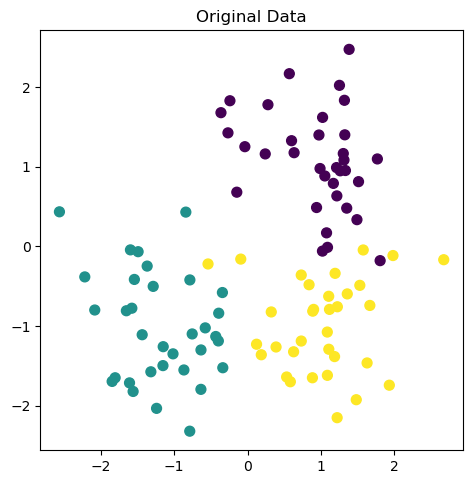

In [4]:
plt.figure(figsize = (12, 12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
plt.title("Original Data")
plt.show()

In [5]:
class KMeansCustom:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.centroids = None
        self.labels_ = None
    
    def fit(self, X):
        n_samples, n_features = X.shape
        # Step 1: Initialize centroids randomly from the data points
        np.random.seed(42)  # For reproducibility
        random_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        while True:

            distance = euclidean_distances(X, self.centroids)
            self.labels_ = np.argmin(distance, axis=1)
            new_centroids = np.array([X[self.labels_ == i].mean(axis=0) for i in range(self.n_clusters)])
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
            self.centroids = new_centroids

In [7]:
from skimage import io
from IPython.display import Image, display

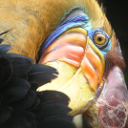

Original image shape: (128, 128, 3)


In [8]:
path_img = 'bird_small.png'
image = io.imread(path_img)
display(Image(filename=path_img))
print("Original image shape:", image.shape)

Compressed KMeans image shape: 


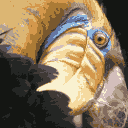

In [11]:
print("Compressed KMeans image shape: ")
kmeans_custom = KMeansCustom(n_clusters=16)
kmeans_custom.fit(image.reshape(-1, 3))
compressed_image_custom = kmeans_custom.centroids[kmeans_custom.labels_].reshape(image.shape)
io.imsave('compressed_kmeans_custom.png', compressed_image_custom.astype(np.uint8))
display(Image(filename='compressed_kmeans_custom.png'))

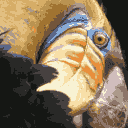

In [12]:
kmeans_sklearn = KMeans(n_clusters=16, random_state=42)
kmeans_sklearn.fit(image.reshape(-1, 3))
compressed_image_sklearn = kmeans_sklearn.cluster_centers_[kmeans_sklearn.labels_].reshape(image.shape)
io.imsave('compressed_kmeans_sklearn.png', compressed_image_sklearn.astype(np.uint8))
display(Image(filename='compressed_kmeans_sklearn.png'))